# Statistical and Probabilistic Analysis of Spotify Popularity

This notebook analyzes Spotify success metrics through descriptive statistics and applies Bayes' theorem to popularity and explicit content.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
NUMERIC_COLUMNS = ["Spotify Popularity", "Spotify Streams", "YouTube Views"]
DISTRIBUTION_COLUMNS = ["Spotify Streams", "YouTube Views"]

DATA_PATH = Path("Most Streamed Spotify Songs 2024.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("P1 Module 1. Python Libraries & Statistics") / "Tareas" / "Spotify" / DATA_PATH

In [2]:
# 1. Data Loading and Preparation
df = pd.read_csv(DATA_PATH, encoding="latin1")

print(f"Loaded: {DATA_PATH.name}")
print(f"Rows and columns: {df.shape}")
df.head()

Loaded: Most Streamed Spotify Songs 2024.csv
Rows and columns: (4600, 29)


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


# Part 1: Descriptive Statistics Analysis

## 1. Data Loading and Preparation

The relevant quantitative columns are converted to numeric values. Invalid entries become missing values, and missing numeric values are replaced with the median of each column.

In [3]:
for column in NUMERIC_COLUMNS:
    df[column] = df[column].astype(str).str.replace(",", "", regex=False)
    df[column] = pd.to_numeric(df[column], errors="coerce")
    df[column] = df[column].fillna(df[column].median())

df["Explicit Track"] = (
    pd.to_numeric(df["Explicit Track"], errors="coerce")
    .fillna(0)
    .eq(1)
)

cleaning_summary = pd.DataFrame({
    "Missing Values After Cleaning": df[NUMERIC_COLUMNS].isna().sum(),
    "Median Used for Imputation": df[NUMERIC_COLUMNS].median(),
})

cleaning_summary

,Missing Values After Cleaning,Median Used for Imputation
Spotify Popularity,0,67.0
Spotify Streams,0,239850720.0
YouTube Views,0,148269610.0


## 2. Visualizing Data Distributions

The histograms below show how Spotify Streams and YouTube Views are distributed across songs. Both variables have right-skewed distributions with a long tail toward the right: most songs are concentrated at lower or moderate values, while a small number of songs accumulate extraordinarily high stream or view counts.

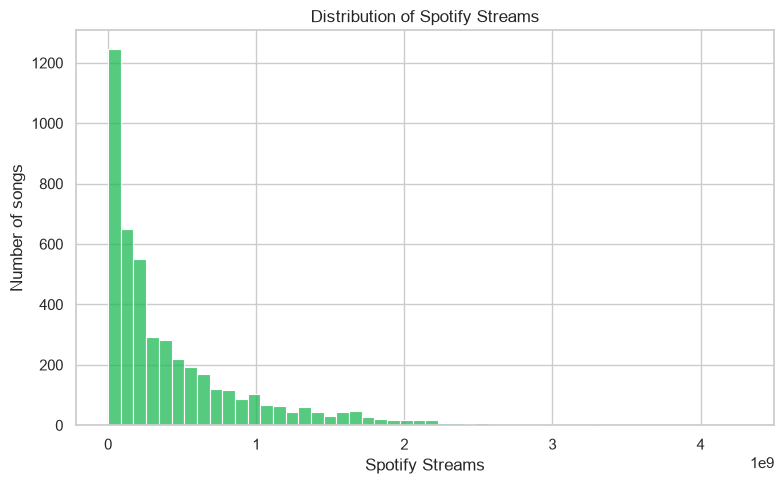

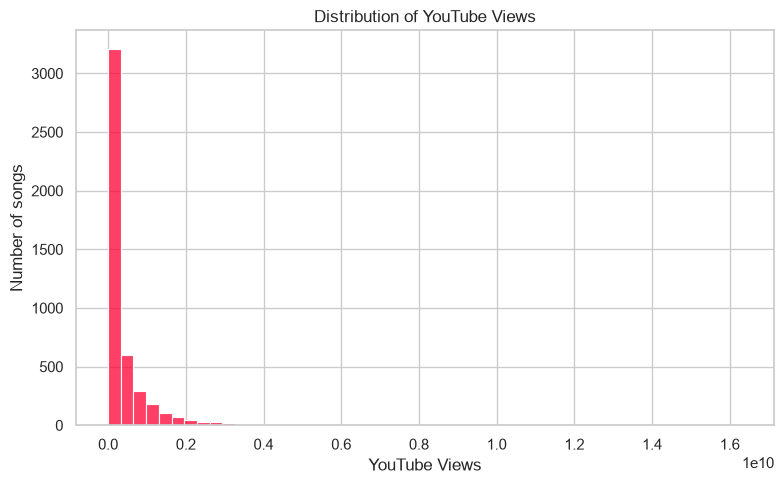

In [4]:
# 2. Visualizing Data Distributions
for column, color in zip(DISTRIBUTION_COLUMNS, ["#1DB954", "#FF0033"]):
    fig, axis = plt.subplots(figsize=(8, 5))
    sns.histplot(df[column], bins=50, ax=axis, color=color)
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Number of songs")
    fig.tight_layout()
    plt.show()


### Interpretation: Histograms

Both histograms are positively skewed, also called right-skewed. The bars are concentrated on the left side, where most songs have comparatively lower stream or view counts, while the distribution stretches far to the right because a few songs achieve exceptionally high success.

This long right tail shows that musical success is highly concentrated. Most tracks receive considerably smaller numbers of streams and views, while relatively few major hits accumulate very large totals.

## 3. Measures of Central Tendency

The mean and median are calculated for Spotify Streams and YouTube Views. Comparing them helps explain how extreme hits affect the average.

In [5]:
# 3. Measures of Central Tendency
central_tendency = df[DISTRIBUTION_COLUMNS].agg(["mean", "median"]).T
central_tendency["Mean / Median Ratio"] = central_tendency["mean"] / central_tendency["median"]
central_tendency

,mean,median,Mean / Median Ratio
Spotify Streams,4.422891e+08,239850720.0,1.844018
YouTube Views,3.857545e+08,148269610.0,2.601710


### Interpretation: Mean vs. Median

Because the distributions have positive skewness and extreme values in the right tail, the mean is pulled toward higher values. A few songs with exceptionally large numbers of streams and views increase the arithmetic average.

The median is more resistant to extreme values because it represents the middle observation after sorting the data. For that reason, it remains closer to the center of the main cluster of observations, while the mean moves toward the right tail.

## 4. Measures of Dispersion and Relative Variability

The standard deviation measures absolute dispersion. The coefficient of variation is calculated as `CV = (standard deviation / mean) * 100`, which compares relative variability across variables with different scales. A lower CV means the metric is more consistent, while a higher CV means it is more volatile relative to its mean.

In [6]:
# 4. Measures of Dispersion and Relative Variability
dispersion = pd.DataFrame({
    "Mean": df[NUMERIC_COLUMNS].mean(),
    "Standard Deviation": df[NUMERIC_COLUMNS].std(),
})
dispersion["CV (%)"] = (
    dispersion["Standard Deviation"] / dispersion["Mean"]
) * 100
dispersion = dispersion.sort_values("CV (%)")
dispersion

,Mean,Standard Deviation,CV (%)
Spotify Popularity,6.411304e+01,1.476358e+01,23.027421
Spotify Streams,4.422891e+08,5.327575e+08,120.454584
YouTube Views,3.857545e+08,6.809681e+08,176.528890


In [7]:
ordered_metrics = dispersion.index.tolist()
print("Order from most consistent to most volatile:")
for position, metric in enumerate(ordered_metrics, start=1):
    cv_value = dispersion.loc[metric, "CV (%)"]
    print(f"{position}. {metric}: CV = {cv_value:.2f}%")

Order from most consistent to most volatile:
1. Spotify Popularity: CV = 23.03%
2. Spotify Streams: CV = 120.45%
3. YouTube Views: CV = 176.53%


### Interpretation: Variability

The metric with the lowest coefficient of variation is the most consistent because its values vary less relative to its mean. The metric with the highest coefficient of variation is the most volatile because its values are more spread out relative to its average.

Using the CV values calculated from this dataset, the order from most consistent to most volatile is Spotify Popularity, Spotify Streams, and YouTube Views. This means popularity scores vary the least in relative terms, while YouTube Views are the most volatile because views are highly concentrated in a smaller group of songs.

# Part 2: Probabilistic Analysis with Bayes' Theorem

This section studies whether knowing that a song has high popularity changes the probability that the song is explicit.

Event A: the song has High Popularity, defined as `Spotify Popularity >= 85`.

Event B: the song is Explicit, given by the `Explicit Track` column.

In [8]:
# 1. Defining Events
HIGH_POPULARITY_THRESHOLD = 85

df["High Popularity"] = df["Spotify Popularity"] >= HIGH_POPULARITY_THRESHOLD
event_a = df["High Popularity"]
event_b = df["Explicit Track"]

event_summary = pd.DataFrame({
    "Event": ["A", "B"],
    "Definition": [
        f"Spotify Popularity >= {HIGH_POPULARITY_THRESHOLD}",
        "Explicit Track is True",
    ],
    "Number of Songs": [event_a.sum(), event_b.sum()],
    "Total Songs": [len(df), len(df)],
})

event_summary

,Event,Definition,Number of Songs,Total Songs
0,A,Spotify Popularity >= 85,54,4600
1,B,Explicit Track is True,1651,4600


## 2. Calculating Prior Probabilities

The probabilities are calculated directly from the dataset by counting how often each event occurs.

In [9]:
# 2. Calculating Prior Probabilities
p_a = event_a.mean()
p_b = event_b.mean()
p_a_given_b = event_a[event_b].mean()

probabilities = pd.DataFrame({
    "Probability": ["P(A)", "P(B)", "P(A|B)"],
    "Meaning": [
        "Probability that a song has High Popularity",
        "Probability that a song is Explicit",
        "Probability that a song has High Popularity given that it is Explicit",
    ],
    "Value": [p_a, p_b, p_a_given_b],
    "Percentage": [p_a * 100, p_b * 100, p_a_given_b * 100],
})

probabilities

,Probability,Meaning,Value,Percentage
0,P(A),Probability that a song has High Popularity,0.011739,1.173913
1,P(B),Probability that a song is Explicit,0.358913,35.891304
2,P(A|B),Probability that a song has High Popularity gi...,0.010902,1.090248


## 3. Applying Bayes' Theorem

Bayes' Theorem is used to calculate the probability that a song is explicit after observing that it has high popularity:

`P(B|A) = [P(A|B) * P(B)] / P(A)`

Using `Spotify Popularity >= 85`, the probabilities calculated from the dataset are approximately `P(A) = 0.011739`, `P(B) = 0.358913`, and `P(A|B) = 0.010902`. Substituting these values gives:

`P(B|A) = [0.010902 * 0.358913] / 0.011739 = 0.333333`

Therefore, the posterior probability is approximately `33.33%`.

In [10]:
if p_a == 0:
    raise ValueError("P(A) is zero, so P(B|A) cannot be calculated.")

p_b_given_a = (p_a_given_b * p_b) / p_a
comparison = "more" if p_b_given_a > p_b else "less" if p_b_given_a < p_b else "equally"

print("Bayes' Theorem:")
print("P(B|A) = [P(A|B) * P(B)] / P(A)")
print(f"P(B|A) = [{p_a_given_b:.6f} * {p_b:.6f}] / {p_a:.6f}")
print(f"P(B|A) = {p_b_given_a:.6f}")
print()
print(f"Posterior probability P(B|A): {p_b_given_a:.2%}")
print(f"Prior probability P(B): {p_b:.2%}")
print(f"Knowing that a song has High Popularity makes it {comparison} likely to be explicit.")

Bayes' Theorem:
P(B|A) = [P(A|B) * P(B)] / P(A)
P(B|A) = [0.010902 * 0.358913] / 0.011739
P(B|A) = 0.333333

Posterior probability P(B|A): 33.33%
Prior probability P(B): 35.89%
Knowing that a song has High Popularity makes it less likely to be explicit.


### Interpretation / Conclusion

The prior probability that a randomly selected song is explicit is `P(B) = 35.89%`. After observing that the song has High Popularity, the posterior probability is `P(B|A) = 33.33%`.

Because the posterior probability is slightly lower than the prior probability, knowing that a song has High Popularity makes it less likely to be explicit in this dataset.

In [ ]:
# Verificar nulos y duplicados ANTES de la limpieza
# Volvemos a leer el CSV original sin modificar el df que ya limpiamos.
df_original = pd.read_csv(DATA_PATH, encoding="latin1")

print("Filas y columnas:", df_original.shape)
print("Total de valores nulos:", df_original.isna().sum().sum())
print("Filas duplicadas exactas (sin contar la primera):", df_original.duplicated().sum())

print("\nValores nulos por columna:")
print(df_original.isna().sum().to_string())

print("\nNulos en las columnas usadas en el análisis:")
print(df_original[NUMERIC_COLUMNS].isna().sum().to_string())
print("Total:", df_original[NUMERIC_COLUMNS].isna().sum().sum())


Filas y columnas: (4600, 29)
Total de valores nulos: 22800
Filas duplicadas exactas (sin contar la primera): 2

Valores nulos por columna:
Track                            0
Album Name                       0
Artist                           5
Release Date                     0
ISRC                             0
All Time Rank                    0
Track Score                      0
Spotify Streams                113
Spotify Playlist Count          70
Spotify Playlist Reach          72
Spotify Popularity             804
YouTube Views                  308
YouTube Likes                  315
TikTok Posts                  1173
TikTok Likes                   980
TikTok Views                   981
YouTube Playlist Reach        1009
Apple Music Playlist Count     561
AirPlay Spins                  498
SiriusXM Spins                2123
Deezer Playlist Count          921
Deezer Playlist Reach          928
Amazon Playlist Count         1055
Pandora Streams               1106
Pandora Track Station